In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset
from flwr.common import Parameters, ndarrays_to_parameters, parameters_to_ndarrays
import flwr as fl
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional, OrderedDict
import threading
import time
import warnings
import logging
import cv2
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc
import hashlib
import pickle

warnings.filterwarnings("ignore", category=DeprecationWarning, module="flwr")
warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("flwr").setLevel(logging.ERROR)
logging.getLogger("flower").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)
logging.getLogger("grpc").setLevel(logging.ERROR)
logging.getLogger("urllib3").setLevel(logging.ERROR)

In [45]:
print("НАСТРОЙКА GPU")
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

if torch.cuda.is_available():
    print(f"Найдено GPU: {torch.cuda.device_count()} устройств")
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
else:
    print("GPU не найден. Используется CPU")

НАСТРОЙКА GPU
Используемое устройство: cuda
Найдено GPU: 1 устройств


In [46]:
final_federated_weights = None
server_round_history = []
centralized_model_accuracy = None

In [64]:
IMAGE_CACHE = {}
CACHE_DIR = "image_cache"
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

path_train = r"C:\Users\User\Desktop\APTOS\train.csv"
path_test = r"C:\Users\User\Desktop\APTOS\test.csv"
path_images = r"C:\Users\User\Desktop\APTOS\train_images"

data_train = pd.read_csv(path_train)
data_test = pd.read_csv(path_test)

data_train["image_path"] = data_train["id_code"].apply(
    lambda x: os.path.join(path_images, x + ".png")
)

In [48]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

def get_image_hash(image_path):
    return hashlib.md5(image_path.encode()).hexdigest()

def load_and_preprocess_image_cached(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)):
    """Загрузка и предобработка изображения с кэшированием в памяти и на диске"""
    if image_path in IMAGE_CACHE:
        return IMAGE_CACHE[image_path]

    cache_file = os.path.join(CACHE_DIR, f"{get_image_hash(image_path)}.pkl")
    if os.path.exists(cache_file):
        try:
            with open(cache_file, 'rb') as f:
                image_tensor = pickle.load(f)
            IMAGE_CACHE[image_path] = image_tensor
            return image_tensor
        except:
            pass

    try:
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, target_size)

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        image_pil = Image.fromarray(image)
        image_tensor = transform(image_pil)

        IMAGE_CACHE[image_path] = image_tensor

        try:
            with open(cache_file, 'wb') as f:
                pickle.dump(image_tensor, f)
        except Exception as e:
            print(f"Не удалось сохранить в кэш: {e}")

        return image_tensor
    except Exception as e:
        print(f"Ошибка при загрузке {image_path}: {e}")
        return None

def load_all_images(all_paths, all_labels, target_size=(IMAGE_SIZE, IMAGE_SIZE)):
    """Загрузка всех изображений с сохранением в глобальную структуру"""
    global IMAGE_CACHE

    print(f"Загрузка всех {len(all_paths)} изображений...")

    all_images_data = {}
    all_labels_dict = {}

    for i, (path, label) in enumerate(zip(all_paths, all_labels)):
        img_tensor = load_and_preprocess_image_cached(path, target_size)

        if img_tensor is not None:
            all_images_data[path] = img_tensor.numpy().astype(np.float16)
            all_labels_dict[path] = label

        if i % 100 == 0 and i > 0:
            print(f"  Загружено {i} изображений...")
            torch.cuda.empty_cache()
            gc.collect()

    print(f"Загружено {len(all_images_data)} изображений. Кэш в памяти: {len(IMAGE_CACHE)}")

    return all_images_data, all_labels_dict

def get_images_by_paths(paths, labels, all_images_data, all_labels_dict):
    """Получение изображений по путям из глобального кэша"""
    images = []
    valid_labels = []

    for path, label in zip(paths, labels):
        if path in all_images_data:
            images.append(all_images_data[path])
            valid_labels.append(all_labels_dict[path])
        else:
            print(f"Предупреждение: изображение {path} не найдено в кэше")

    if len(images) > 0:
        images_array = np.array(images, dtype=np.float16)
        labels_array = np.array(valid_labels)
        return images_array, labels_array
    else:
        return np.array([]), np.array([])

In [49]:
print("ЗАГРУЗКА ВСЕХ ИЗОБРАЖЕНИЙ")

all_paths = data_train["image_path"].values
all_labels = data_train["diagnosis"].values

all_images_data, all_labels_dict = load_all_images(all_paths, all_labels)

print(f"\nВсе изображения загружены и закэшированы!")
print(f"Всего уникальных изображений в кэше: {len(all_images_data)}")

ЗАГРУЗКА ВСЕХ ИЗОБРАЖЕНИЙ
Загрузка всех 3662 изображений...
  Загружено 100 изображений...
  Загружено 200 изображений...
  Загружено 300 изображений...
  Загружено 400 изображений...
  Загружено 500 изображений...
  Загружено 600 изображений...
  Загружено 700 изображений...
  Загружено 800 изображений...
  Загружено 900 изображений...
  Загружено 1000 изображений...
  Загружено 1100 изображений...
  Загружено 1200 изображений...
  Загружено 1300 изображений...
  Загружено 1400 изображений...
  Загружено 1500 изображений...
  Загружено 1600 изображений...
  Загружено 1700 изображений...
  Загружено 1800 изображений...
  Загружено 1900 изображений...
  Загружено 2000 изображений...
  Загружено 2100 изображений...
  Загружено 2200 изображений...
  Загружено 2300 изображений...
  Загружено 2400 изображений...
  Загружено 2500 изображений...
  Загружено 2600 изображений...
  Загружено 2700 изображений...
  Загружено 2800 изображений...
  Загружено 2900 изображений...
  Загружено 3000 изоб

In [50]:
def split_clients_custom(train_df):
    """Разделение данных на клиентов (только пути и метки)"""
    clients = []

    for client_id in range(1, 6):
        if client_id == 1:
            condition = train_df['diagnosis'] == 0
        elif client_id == 2:
            condition = train_df['diagnosis'] == 1
        elif client_id == 3:
            condition = train_df['diagnosis'] == 2
        elif client_id == 4:
            condition = train_df['diagnosis'] == 3
        else:
            condition = train_df['diagnosis'] == 4

        client_df = train_df[condition]
        print(f"Клиент {client_id}: {len(client_df)} изображений")

        paths = client_df["image_path"].values
        labels = client_df["diagnosis"].values

        clients.append((paths, labels))

    return clients

In [51]:
print("Разделение данных на клиентов...")
client_data_paths_labels = split_clients_custom(data_train)

client_data = []
for client_id, (paths, labels) in enumerate(client_data_paths_labels):
    print(f"\nПодготовка данных для клиента {client_id+1}...")

    images, labels_loaded = get_images_by_paths(paths, labels, all_images_data, all_labels_dict)

    if len(images) > 0:
        x_train, x_test, y_train, y_test = train_test_split(
            images, labels_loaded, test_size=0.2, random_state=42, stratify=labels_loaded
        )
        client_data.append((x_train, y_train, x_test, y_test))
        print(f"Клиент {client_id+1}: {len(x_train)} тренировочных, {len(x_test)} тестовых изображений")
    else:
        print(f"Клиент {client_id+1}: нет изображений")
        client_data.append((np.array([]), np.array([]), np.array([]), np.array([])))

num_clients = len([data for data in client_data if len(data[0]) > 0])

print(f"\nВсего клиентов с данными: {num_clients}")
print("\nПодготовка централизованных данных из кэша...")

central_paths = all_paths
central_labels = all_labels

x_central, y_central = get_images_by_paths(central_paths, central_labels, all_images_data, all_labels_dict)
x_train_central, x_test_central, y_train_central, y_test_central = train_test_split(
    x_central, y_central, test_size=0.2, random_state=42, stratify=y_central
)

print(f"Централизованные данные: {len(x_train_central)} тренировочных, {len(x_test_central)} тестовых изображений")

del all_images_data, all_labels_dict
torch.cuda.empty_cache()
gc.collect()

print("ОПТИМИЗАЦИЯ ПАМЯТИ")
print(f"Кэш изображений в памяти: {len(IMAGE_CACHE)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Размер изображений: {IMAGE_SIZE}x{IMAGE_SIZE}")

Разделение данных на клиентов...
Клиент 1: 1805 изображений
Клиент 2: 370 изображений
Клиент 3: 999 изображений
Клиент 4: 193 изображений
Клиент 5: 295 изображений

Подготовка данных для клиента 1...
Клиент 1: 1444 тренировочных, 361 тестовых изображений

Подготовка данных для клиента 2...
Клиент 2: 296 тренировочных, 74 тестовых изображений

Подготовка данных для клиента 3...
Клиент 3: 799 тренировочных, 200 тестовых изображений

Подготовка данных для клиента 4...
Клиент 4: 154 тренировочных, 39 тестовых изображений

Подготовка данных для клиента 5...
Клиент 5: 236 тренировочных, 59 тестовых изображений

Всего клиентов с данными: 5

Подготовка централизованных данных из кэша...
Централизованные данные: 2929 тренировочных, 733 тестовых изображений
ОПТИМИЗАЦИЯ ПАМЯТИ
Кэш изображений в памяти: 3662
Batch size: 16
Размер изображений: 224x224


In [52]:
def prepare_data(x_data, y_data):
    """Подготовка данных в формате PyTorch"""
    if len(x_data) == 0 or len(y_data) == 0:
        return TensorDataset(torch.FloatTensor([]), torch.LongTensor([]))
    x_tensor = torch.FloatTensor(x_data.astype(np.float32))
    y_tensor = torch.LongTensor(y_data)
    return TensorDataset(x_tensor, y_tensor)

In [53]:
class AptosCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(AptosCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192 * 14 * 14, 384),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(384, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def create_model(num_classes=5):
    model = AptosCNN(num_classes=num_classes)
    return model.to(device)

print("\nАрхитектура модели APTOS:")
model = create_model()
total_params = sum(p.numel() for p in model.parameters())
print(f"Размер модели: {total_params:,} параметров")
print(f"Размер в памяти: {total_params * 4 / 1024**2:.2f} MB (float32)")


Архитектура модели APTOS:
Размер модели: 14,841,413 параметров
Размер в памяти: 56.62 MB (float32)


In [54]:
class AptosClient(fl.client.NumPyClient):
    def __init__(self, client_id: int):
        self.client_id = client_id
        self.model = create_model()
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.scaler = torch.cuda.amp.GradScaler()

        x_train, y_train, x_test, y_test = client_data[client_id]
        self.train_dataset = prepare_data(x_train, y_train)
        self.test_dataset = prepare_data(x_test, y_test)

        self.has_data = len(x_train) > 0
        self.training_history = []

    def get_parameters(self, config):
        """Получение параметров модели как списка numpy массивов"""
        torch.cuda.empty_cache()
        gc.collect()

        params = [val.cpu().numpy() for val in self.model.state_dict().values()]
        return params

    def set_parameters(self, parameters):
        """Установка параметров модели из списка numpy массивов"""
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.from_numpy(v).to(device) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        try:
            if not self.has_data:
                print(f"Клиент {self.client_id}: нет данных для обучения")
                return parameters, 0, {"client_id": self.client_id, "accuracy": 0.0, "loss": 10.0}

            torch.cuda.empty_cache()
            gc.collect()

            self.set_parameters(parameters)

            epochs = config.get("local_epochs", 1)
            batch_size = config.get("batch_size", BATCH_SIZE)

            train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)

            print(f"Клиент {self.client_id}: обучение на {len(self.train_dataset)} изображениях, batch_size={batch_size}")

            self.model.train()
            total_loss = 0
            correct = 0
            total = 0

            for epoch in range(epochs):
                epoch_loss = 0
                epoch_correct = 0
                epoch_total = 0

                for batch_idx, (data, target) in enumerate(train_loader):
                    data, target = data.to(device), target.to(device)

                    self.optimizer.zero_grad()

                    with torch.cuda.amp.autocast():
                        output = self.model(data)
                        loss = self.criterion(output, target)

                    self.scaler.scale(loss).backward()
                    self.scaler.step(self.optimizer)
                    self.scaler.update()

                    epoch_loss += loss.item()
                    _, predicted = output.max(1)
                    epoch_total += target.size(0)
                    epoch_correct += predicted.eq(target).sum().item()

                    if batch_idx % 5 == 0:
                        torch.cuda.empty_cache()
                        gc.collect()

                total_loss += epoch_loss
                correct += epoch_correct
                total += epoch_total

                print(f"  Эпоха {epoch+1}: точность: {epoch_correct/epoch_total:.4f}, ошибка: {epoch_loss/len(train_loader):.4f}")

            accuracy = correct / total if total > 0 else 0.0
            avg_loss = total_loss / (epochs * len(train_loader)) if len(train_loader) > 0 else 10.0

            print(f"Клиент {self.client_id}: итоговая точность: {accuracy:.4f}, ошибка: {avg_loss:.4f}")

            torch.cuda.empty_cache()
            gc.collect()

            return self.get_parameters({}), len(self.train_dataset), {
                "client_id": self.client_id,
                "accuracy": accuracy,
                "loss": avg_loss
            }
        except Exception as e:
            print(f"Клиент {self.client_id}: ошибка в fit - {e}")
            torch.cuda.empty_cache()
            gc.collect()
            return parameters, 0, {"client_id": self.client_id, "accuracy": 0.0, "loss": 10.0}

    def evaluate(self, parameters, config):
        try:
            if not self.has_data:
                print(f"Клиент {self.client_id}: нет данных для оценки")
                return float(10.0), 0, {"accuracy": 0.0}

            self.set_parameters(parameters)

            batch_size = config.get("batch_size", BATCH_SIZE)
            test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)

            self.model.eval()
            test_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for data, target in test_loader:
                    data, target = data.to(device), target.to(device)
                    output = self.model(data)
                    test_loss += self.criterion(output, target).item()
                    _, predicted = output.max(1)
                    total += target.size(0)
                    correct += predicted.eq(target).sum().item()

            accuracy = correct / total if total > 0 else 0.0
            avg_loss = test_loss / len(test_loader) if len(test_loader) > 0 else 10.0

            print(f"Клиент {self.client_id}: тестовая точность: {accuracy:.4f}, ошибка: {avg_loss:.4f}")

            return float(avg_loss), len(self.test_dataset), {"accuracy": float(accuracy)}
        except Exception as e:
            print(f"Клиент {self.client_id}: ошибка в evaluate - {e}")
            return float(10.0), len(self.test_dataset), {"accuracy": 0.0}

In [55]:
class WeightSavingFedAvg(fl.server.strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)

        if aggregated_parameters is not None:
            global final_federated_weights
            final_federated_weights = fl.common.parameters_to_ndarrays(aggregated_parameters)

            global server_round_history
            round_info = {
                'round': server_round,
                'weights': final_federated_weights,
                'metrics': aggregated_metrics,
                'clients_processed': len(results),
                'failures': len(failures)
            }
            server_round_history.append(round_info)

            print(f"Сервер: сохранены усредненные веса раунда {server_round}")
            print(f"Успешных клиентов: {len(results)}, Ошибок: {len(failures)}")

            torch.cuda.empty_cache()
            gc.collect()

        return aggregated_parameters, aggregated_metrics

In [56]:
def fit_config(server_round: int):
    return {
        "local_epochs": 2,
        "batch_size": BATCH_SIZE,
    }

def evaluate_config(server_round: int):
    return {"batch_size": BATCH_SIZE}

def weighted_average(metrics: List[Tuple[int, Dict]]):
    if metrics and "accuracy" in metrics[0][1]:
        accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
        examples = [num_examples for num_examples, _ in metrics]
        if sum(examples) > 0:
            accuracy = sum(accuracies) / sum(examples)
            print(f"Средняя точность клиентов: {accuracy:.4f}")
            return {"accuracy": accuracy}
    return {"accuracy": 0.0}

In [57]:
def train_centralized_model():
    global centralized_model_accuracy
    centralized_model = create_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(centralized_model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()  # Для смешанной точности

    print("ОБУЧЕНИЕ ЦЕНТРАЛИЗОВАННОЙ МОДЕЛИ")

    train_dataset = prepare_data(x_train_central, y_train_central)
    test_dataset = prepare_data(x_test_central, y_test_central)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

    best_val_loss = float('inf')
    patience_counter = 0
    max_patience = 5

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(10):
        torch.cuda.empty_cache()
        gc.collect()

        centralized_model.train()
        train_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                output = centralized_model(data)
                loss = criterion(output, target)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()

        centralized_model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = centralized_model(data)
                val_loss += criterion(output, target).item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        avg_train_loss = train_loss / len(train_loader) if len(train_loader) > 0 else 0
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_accuracy = correct / total if total > 0 else 0

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)

        print(f"Эпоха {epoch+1}: Тренировочная ошибка: {avg_train_loss:.4f}, Валидационная ошибка: {avg_val_loss:.4f}, Валидационная точность: {val_accuracy:.4f}")

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = centralized_model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                print("Ранняя остановка!")
                centralized_model.load_state_dict(best_model_state)
                break

    torch.cuda.empty_cache()
    gc.collect()

    centralized_model.eval()
    test_loss = 0
    correct = 0
    total = 0

    full_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for data, target in full_test_loader:
            data, target = data.to(device), target.to(device)
            output = centralized_model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    test_accuracy = correct / total if total > 0 else 0
    centralized_model_accuracy = test_accuracy

    print(f"\nРезультаты централизованной модели:")
    print(f"Точность на тестовых данных: {test_accuracy:.4f}")
    print(f"Лучшая ошибка на валидации: {best_val_loss:.4f}")

    return test_accuracy, centralized_model, history

In [58]:
def start_complete_federated_system(port=8085):
    global final_federated_weights, server_round_history, centralized_model_accuracy
    final_federated_weights = None
    server_round_history = []
    centralized_model_accuracy = None

    centralized_accuracy, centralized_model, _ = train_centralized_model()

    strategy = WeightSavingFedAvg(
        fraction_fit=1.0,
        fraction_evaluate=0.5,
        min_fit_clients=2,
        min_evaluate_clients=1,
        min_available_clients=2,
        evaluate_metrics_aggregation_fn=weighted_average,
        on_fit_config_fn=fit_config,
        on_evaluate_config_fn=evaluate_config,
    )

    def run_client(client_id):
        try:
            print(f"Клиент {client_id}: подключение к серверу")
            client = AptosClient(client_id)
            fl.client.start_numpy_client(
                server_address=f"127.0.0.1:{port}",
                client=client
            )
            print(f"Клиент {client_id}: завершил работу")
        except Exception as e:
            print(f"Клиент {client_id}: ошибка подключения - {e}")

    def start_all_clients():
        time.sleep(10)

        client_threads = []
        for i in range(num_clients):
            thread = threading.Thread(
                target=run_client,
                args=(i,),
                daemon=True
            )
            client_threads.append(thread)
            thread.start()
            print(f"Клиент {i}: запущен")
            time.sleep(2)

        for thread in client_threads:
            thread.join(timeout=300)

    clients_thread = threading.Thread(target=start_all_clients, daemon=True)
    clients_thread.start()

    try:
        print("\nЗАПУСК ФЕДЕРАТИВНОГО ОБУЧЕНИЯ")

        fl.server.start_server(
            server_address=f"0.0.0.0:{port}",
            config=fl.server.ServerConfig(num_rounds=3),
            strategy=strategy,
            grpc_max_message_length=1024*1024*1024
        )

        print("\nФедеративное обучение завершено")

        if final_federated_weights is not None:
            federated_accuracy = evaluate_federated_model()
            compare_models(federated_accuracy, centralized_accuracy, centralized_model)

            return federated_accuracy, centralized_accuracy
        else:
            print("Веса не были сохранены")
            return None, centralized_accuracy

    except Exception as e:
        print(f"\nОшибка сервера: {e}")
        return None, centralized_accuracy

In [59]:
def evaluate_federated_model():
    if final_federated_weights is None:
        print("Агрегированные веса не сохранены.")
        return None

    federated_model = create_model()

    params_dict = zip(federated_model.state_dict().keys(), final_federated_weights)
    state_dict = OrderedDict({k: torch.from_numpy(v).to(device) for k, v in params_dict})
    federated_model.load_state_dict(state_dict, strict=True)

    print("ОЦЕНКА ФЕДЕРАТИВНОЙ МОДЕЛИ")

    test_dataset = prepare_data(x_test_central, y_test_central)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    federated_model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = federated_model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    test_accuracy = correct / total if total > 0 else 0
    avg_loss = test_loss / len(test_loader) if len(test_loader) > 0 else 0

    print(f"\nРезультаты федеративной модели:")
    print(f"Точность на тестовых данных: {test_accuracy:.4f}")
    print(f"Ошибка на тестовых данных: {avg_loss:.4f}")

    if server_round_history:
        print(f"\nИстория раундов обучения:")
        for round_info in server_round_history:
            print(f"Раунд {round_info['round']}: {round_info['clients_processed']} клиентов, {round_info['failures']} ошибок")

    return test_accuracy

In [60]:
def compare_models(federated_accuracy, centralized_accuracy, centralized_model):
    if federated_accuracy is None or centralized_accuracy is None:
        print("Недостаточно данных для сравнения")
        return

    print("СРАВНЕНИЕ МОДЕЛЕЙ")
    print("Централизованная модель:")
    print(f"Точность: {centralized_accuracy:.4f}")
    print("\nФедеративная модель:")
    print(f"Точность: {federated_accuracy:.4f}")

    difference = federated_accuracy - centralized_accuracy
    difference_percent = difference * 100

    print(f"\nРазница результатов:")
    print(f"Абсолютная: {difference:+.4f}")
    print(f"Относительная: {difference_percent:+.2f}%")

    if difference > 0:
        print("\nФедеративное обучение показало лучший результат!")
    elif difference < 0:
        print("\nЦентрализованное обучение показало лучший результат")
    else:
        print("\nРезультаты одинаковые")

    models = ['Централизованная', 'Федеративная']
    accuracies = [centralized_accuracy, federated_accuracy]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=['skyblue', 'lightcoral'], alpha=0.7)
    plt.ylabel('Точность')
    plt.title('Сравнение централизованного и федеративного обучения')
    plt.ylim(0, 1)

    for bar, accuracy in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

In [61]:
def check_port(port):
    import socket
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    try:
        sock.bind(('0.0.0.0', port))
        sock.close()
        return True
    except socket.error:
        return False

Порт 8086 доступен для использования
ОБУЧЕНИЕ ЦЕНТРАЛИЗОВАННОЙ МОДЕЛИ
Эпоха 1: Тренировочная ошибка: 1.8001, Валидационная ошибка: 0.9414, Валидационная точность: 0.6847
Эпоха 2: Тренировочная ошибка: 1.0490, Валидационная ошибка: 1.0214, Валидационная точность: 0.6528
Эпоха 3: Тренировочная ошибка: 1.0080, Валидационная ошибка: 0.9316, Валидационная точность: 0.6986
Эпоха 4: Тренировочная ошибка: 0.9855, Валидационная ошибка: 1.0862, Валидационная точность: 0.6694
Эпоха 5: Тренировочная ошибка: 0.9648, Валидационная ошибка: 0.9055, Валидационная точность: 0.7153
Эпоха 6: Тренировочная ошибка: 0.9980, Валидационная ошибка: 0.9150, Валидационная точность: 0.7194
Эпоха 7: Тренировочная ошибка: 0.9638, Валидационная ошибка: 0.9858, Валидационная точность: 0.6792
Эпоха 8: Тренировочная ошибка: 0.9394, Валидационная ошибка: 0.8641, Валидационная точность: 0.7167
Эпоха 9: Тренировочная ошибка: 0.9333, Валидационная ошибка: 0.9407, Валидационная точность: 0.6917
Эпоха 10: Тренировочная ошибка

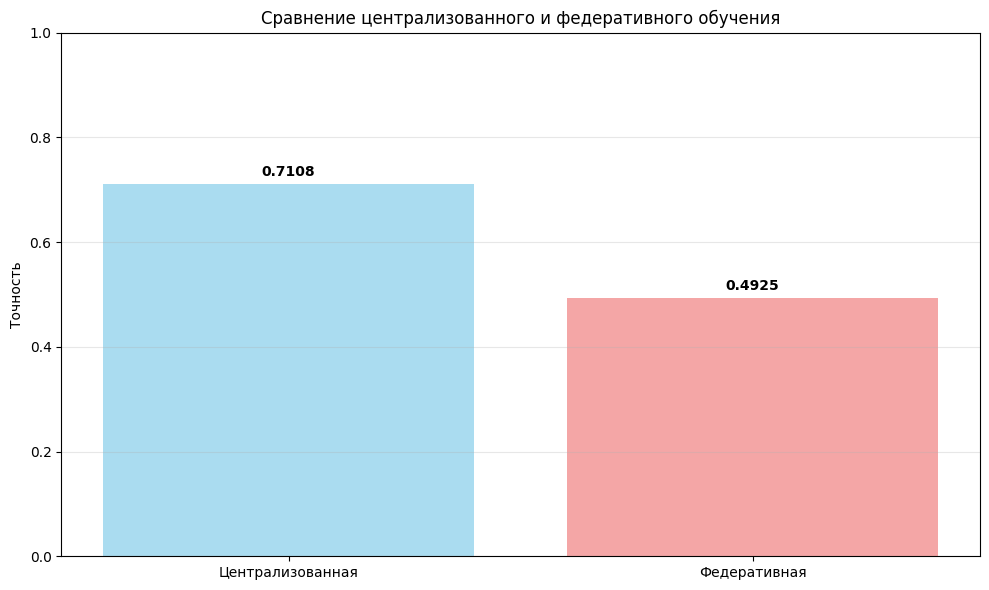

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Финальная точность федеративной модели: 0.4925
Финальная точность централизованной модели: 0.7108

Итоговое изменение точности: -30.71%
Централизованное обучение показало лучший результат


In [62]:
if __name__ == "__main__":
    for port in [8086, 8087, 8088, 8089, 8090]:
        if check_port(port):
            print(f"Порт {port} доступен для использования")
            if num_clients >= 2:
                federated_acc, centralized_acc = start_complete_federated_system(port)

                print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")

                if federated_acc is not None:
                    print(f"Финальная точность федеративной модели: {federated_acc:.4f}")
                print(f"Финальная точность централизованной модели: {centralized_acc:.4f}")

                if federated_acc is not None and centralized_acc is not None:
                    improvement = ((federated_acc - centralized_acc) / centralized_acc) * 100
                    print(f"\nИтоговое изменение точности: {improvement:+.2f}%")

                    if improvement > 0:
                        print("Федеративное обучение улучшило результат!")
                    elif improvement < 0:
                        print("Централизованное обучение показало лучший результат")
                    else:
                        print("Результаты одинаковы")
            else:
                print("Недостаточно клиентов для федеративного обучения. Обучаем только централизованную модель.")
                train_centralized_model()
            break
    else:
        print("Не удалось найти свободный порт!")